In [7]:
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pylab as plt
import seaborn as sns
from sklearn import metrics

In [3]:
# Read in the cleaned data
df = pd.read_csv('/credit allocation/clean_data.csv')
df.head()

,loan_amnt,int_rate,annual_inc,dti,fico_range_low,default,term_ 60 months,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,emp_length_10+ years,emp_length_2 years,emp_length_3 years,emp_length_4 years,emp_length_5 years,emp_length_6 years,emp_length_7 years,emp_length_8 years,emp_length_9 years,emp_length_< 1 year,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,3600.0,13.99,55000.0,5.91,675.0,0,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,24700.0,11.99,65000.0,16.06,715.0,0,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,20000.0,10.78,63000.0,10.78,695.0,0,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,10400.0,22.45,104433.0,25.37,695.0,0,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4,11950.0,13.44,34000.0,10.20,690.0,0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True


In [17]:
df.columns

Index(['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low',
       'default', 'term_ 60 months', 'grade_B', 'grade_C', 'grade_D',
       'grade_E', 'grade_F', 'grade_G', 'emp_length_10+ years',
       'emp_length_2 years', 'emp_length_3 years', 'emp_length_4 years',
       'emp_length_5 years', 'emp_length_6 years', 'emp_length_7 years',
       'emp_length_8 years', 'emp_length_9 years', 'emp_length_< 1 year',
       'home_ownership_MORTGAGE', 'home_ownership_NONE',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT'],
      dtype='object')

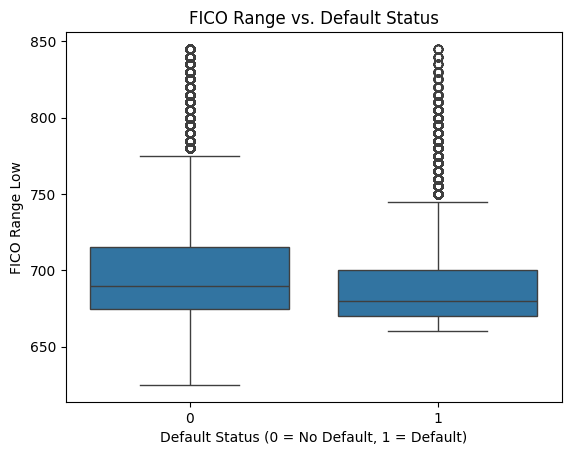

In [12]:
# FICO vs. Default Status
sns.boxplot(x='default', y='fico_range_low', data=df)
plt.title('FICO Range vs. Default Status')
plt.xlabel('Default Status (0 = No Default, 1 = Default)')
plt.ylabel('FICO Range Low')
plt.show()

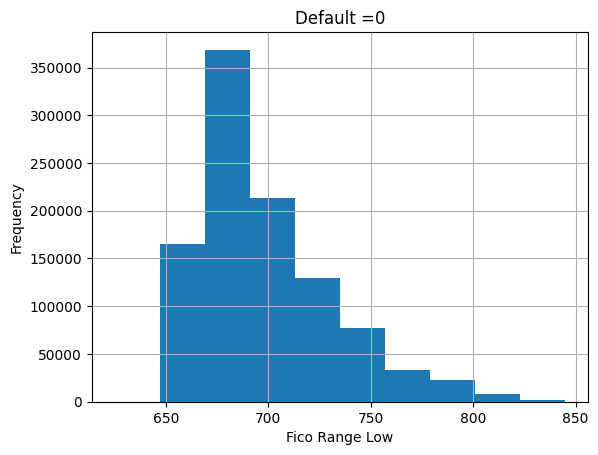

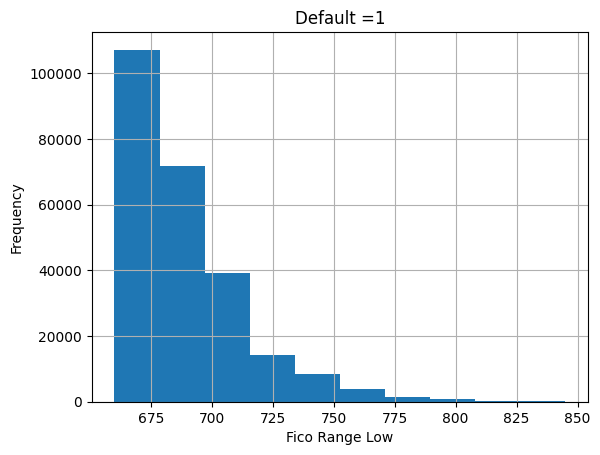

In [14]:
for r in range(2):
    hist = df[df.default == r].hist('fico_range_low')
    plt.title("Default =" + str(r))
    plt.xlabel('Fico Range Low') # Add x-axis label
    plt.ylabel('Frequency') # Add y-axis label
    plt.show()

FICO scores are a measure of credit and lending history. The higher the FICO score, the more reliably the borrower is. By definition, it's no surprise that low FICO scores are more closely associated and correlated with default than high FICO scores.

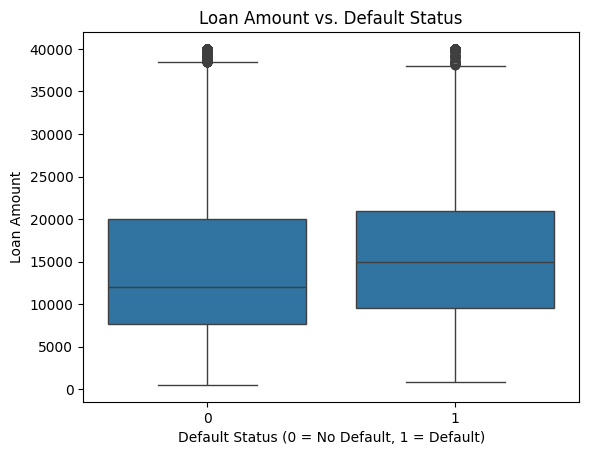

In [15]:
# Loan Amnt vs. Default Status
sns.boxplot(x='default', y='loan_amnt', data=df)
plt.title('Loan Amount vs. Default Status')
plt.xlabel('Default Status (0 = No Default, 1 = Default)')
plt.ylabel('Loan Amount')
plt.show()

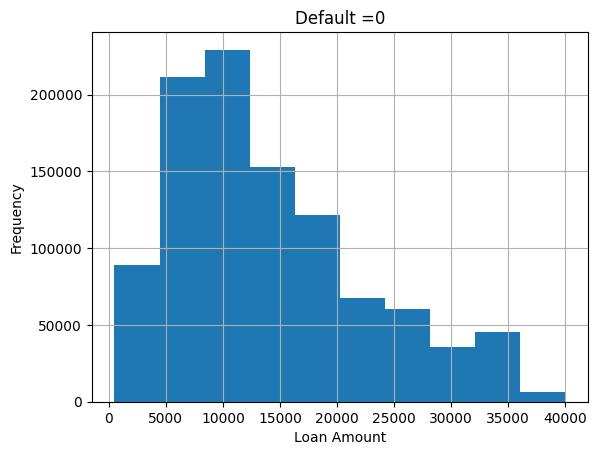

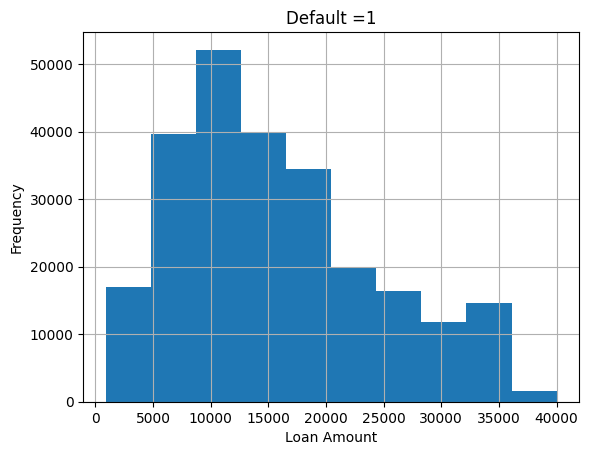

In [32]:
for r in range(2):
    hist = df[df.default == r].hist('loan_amnt')
    plt.title("Default =" + str(r))
    plt.xlabel('Loan') # Add x-axis label
    plt.ylabel('Frequency') # Add y-axis label
    plt.show()

Though the mean of loan amounts by default status differs, the distrbution of both loan amounts are similar. Both are not normal and have similar modes, which is indicative of what loan amounts and types are popular amongst loaners

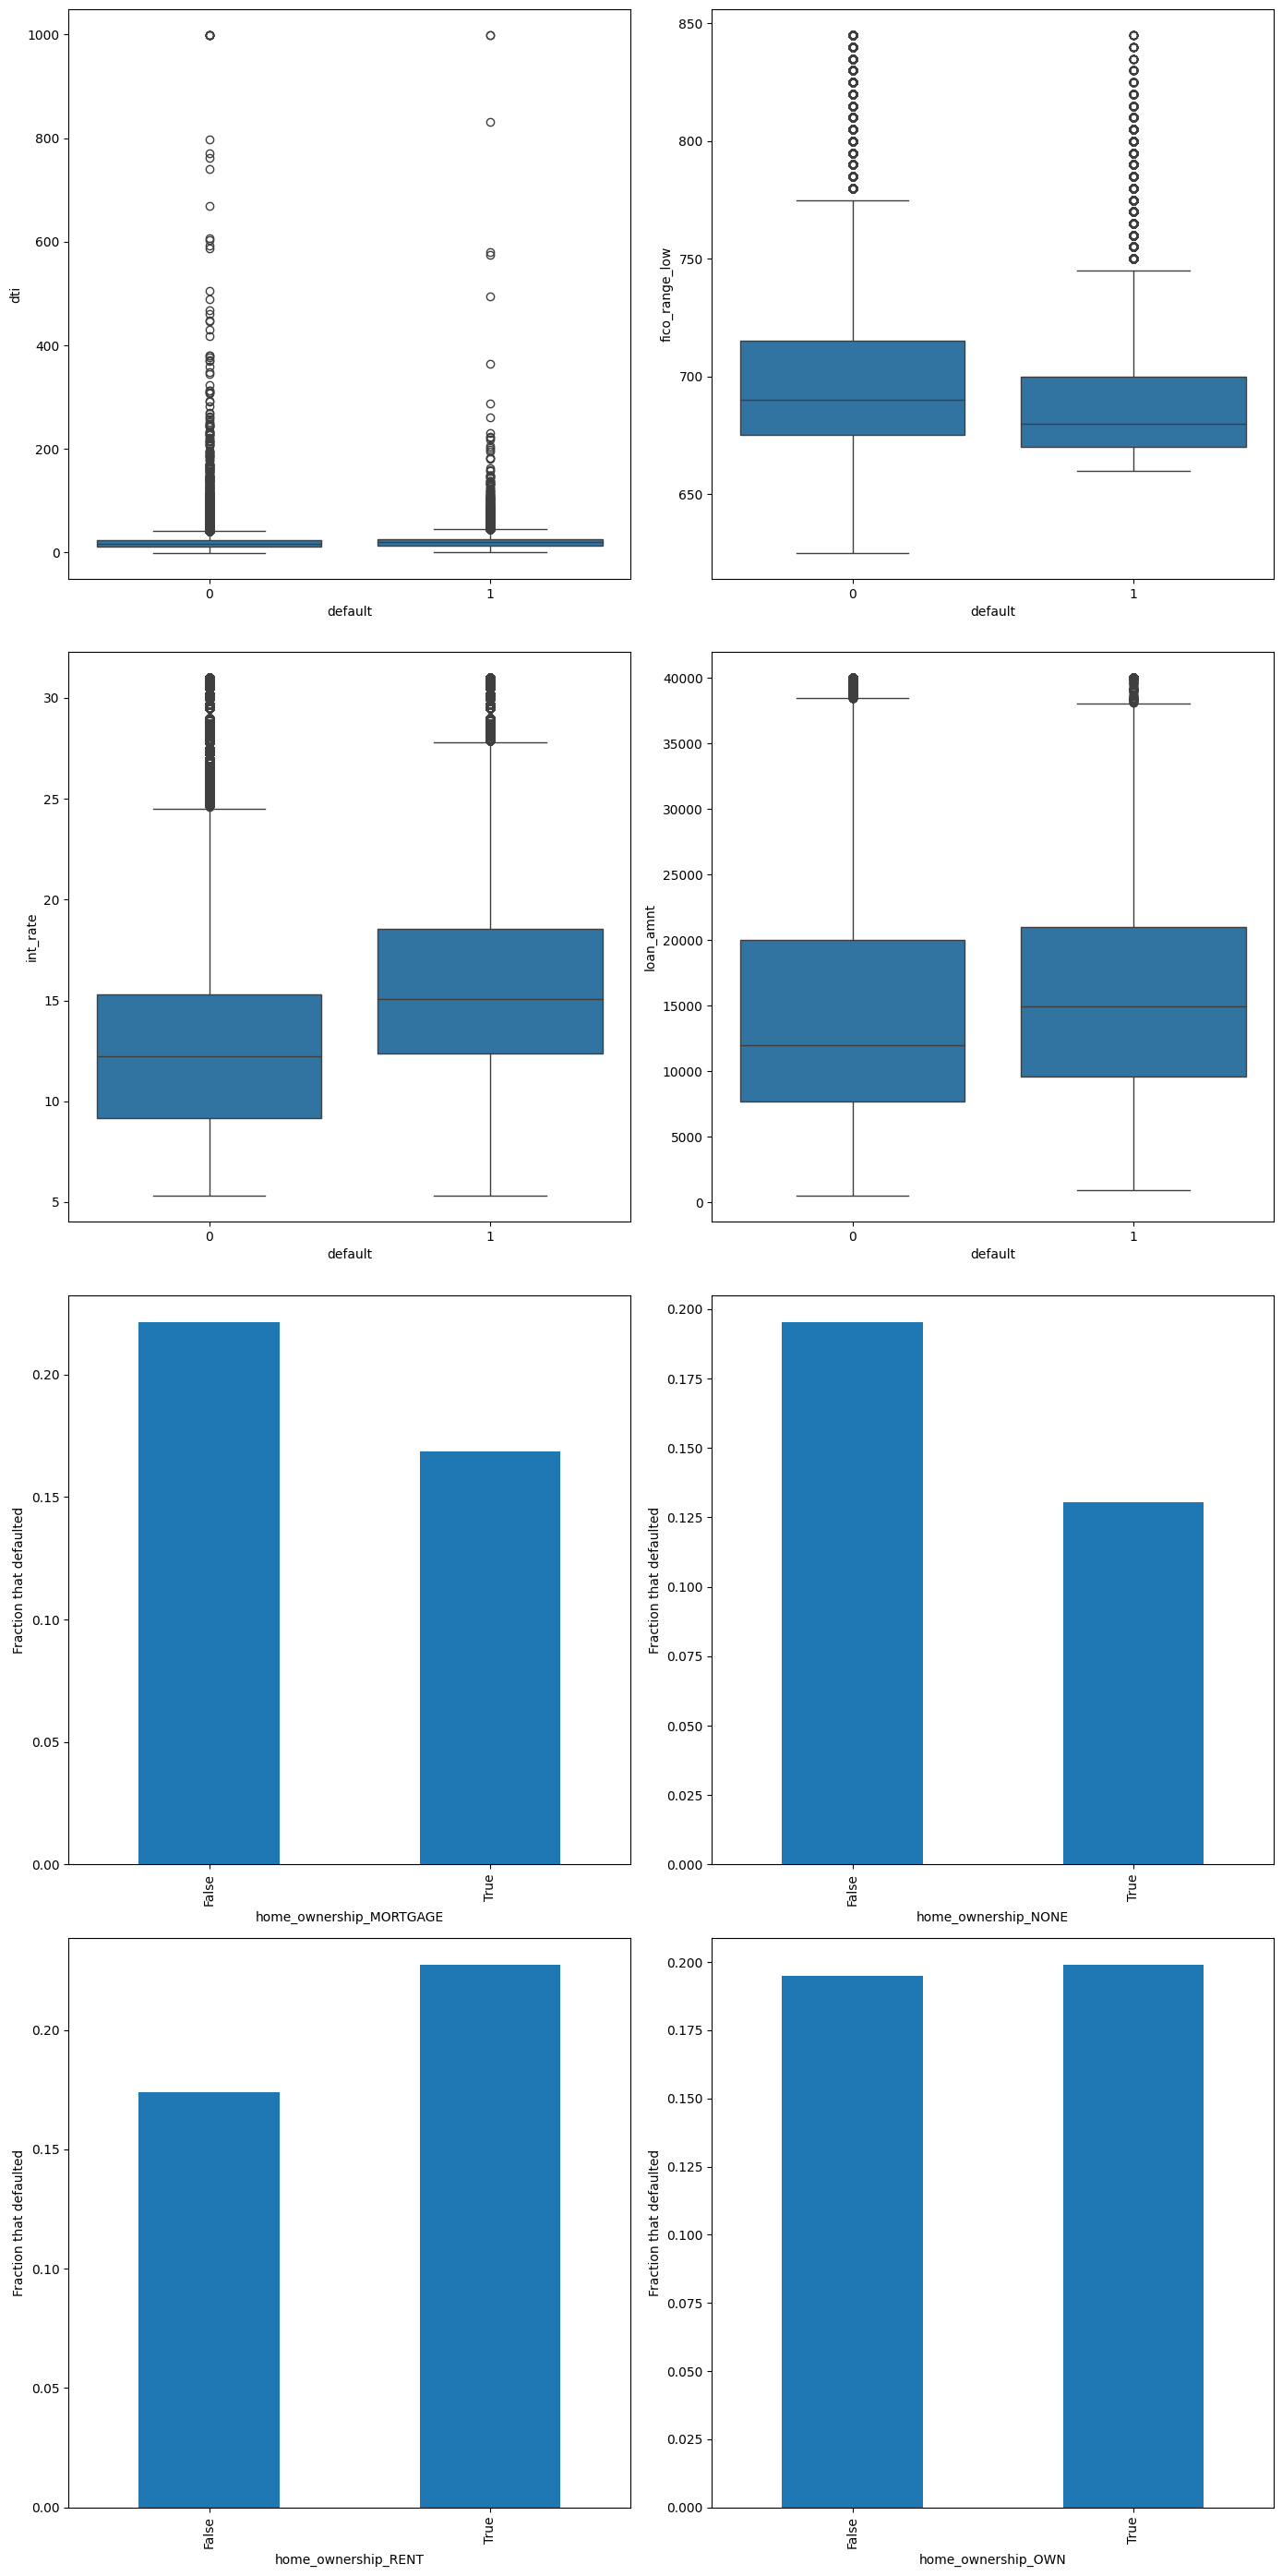

In [22]:
# Home Ownership and Loan Terms
categorical_cols = ["home_ownership_MORTGAGE", "home_ownership_NONE", "home_ownership_RENT", "home_ownership_OWN"]
continuous_cols = ["dti", "fico_range_low", "int_rate", "loan_amnt"]
target_col = "default"
predictor_cols = categorical_cols + continuous_cols

# This is to plot everything in a 3x2 space
rows, cols = 4, 2
fig, axs = plt.subplots(ncols=cols, nrows=rows, figsize=(7*cols, 7*rows))
axs = axs.flatten()
posn = 0

# Plot continuous features
for col in continuous_cols:
    sns.boxplot(x=target_col, y=col, data=df, ax=axs[posn])
    axs[posn].set_ylabel(col)
    axs[posn].set_title("")
    posn += 1

# Plot categorical features
for col in categorical_cols:
    df.groupby(col)[target_col].mean().plot(kind="bar", ax=axs[posn])
    axs[posn].set_ylabel("Fraction that defaulted")
    posn += 1

plt.tight_layout()

*   Higher interest rates, higher loan amounts and lower fico scores are correlated to defaulting. Higher interest rates and higher loan amounts might indicate that the loan is unreasonable to pay off, but this needs to be considered against the debt-to-income ratio to determine if the loan is within the means of the loaner. Low fico scores is generally a description of the loaner's financial health w.r.t. debt and that is reflected in the default performance.
*   Loaners who rented homes had a higher frequency of default, as compared to people who owned homes, where the split was 50/50 and more indicative of having no correlation.
*   The converse was true for loaners who had either a mortage, or no reported form of home ownership.


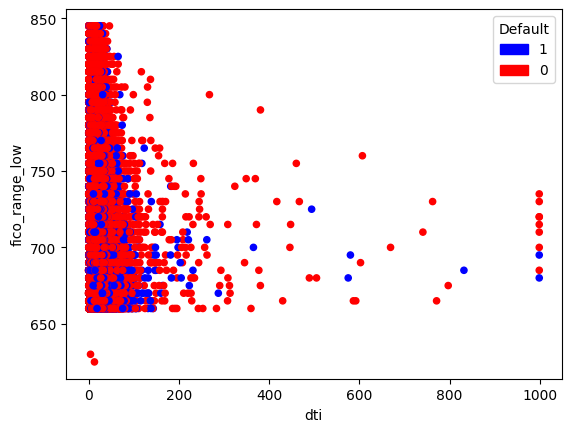

In [53]:
cmap = {1: 'blue', 0: 'red'}
df.plot(kind="scatter", x="dti", y="fico_range_low", c=[cmap[c] for c in df['default']])
plt.legend(handles=[mpatches.Patch(color=cmap[k], label=k) for k in cmap], loc=1, title="Default", frameon=True)
plt.show()

We can see that even if the debt to income ratio is high, defaults are still more heavily associated with lower FICO scores.

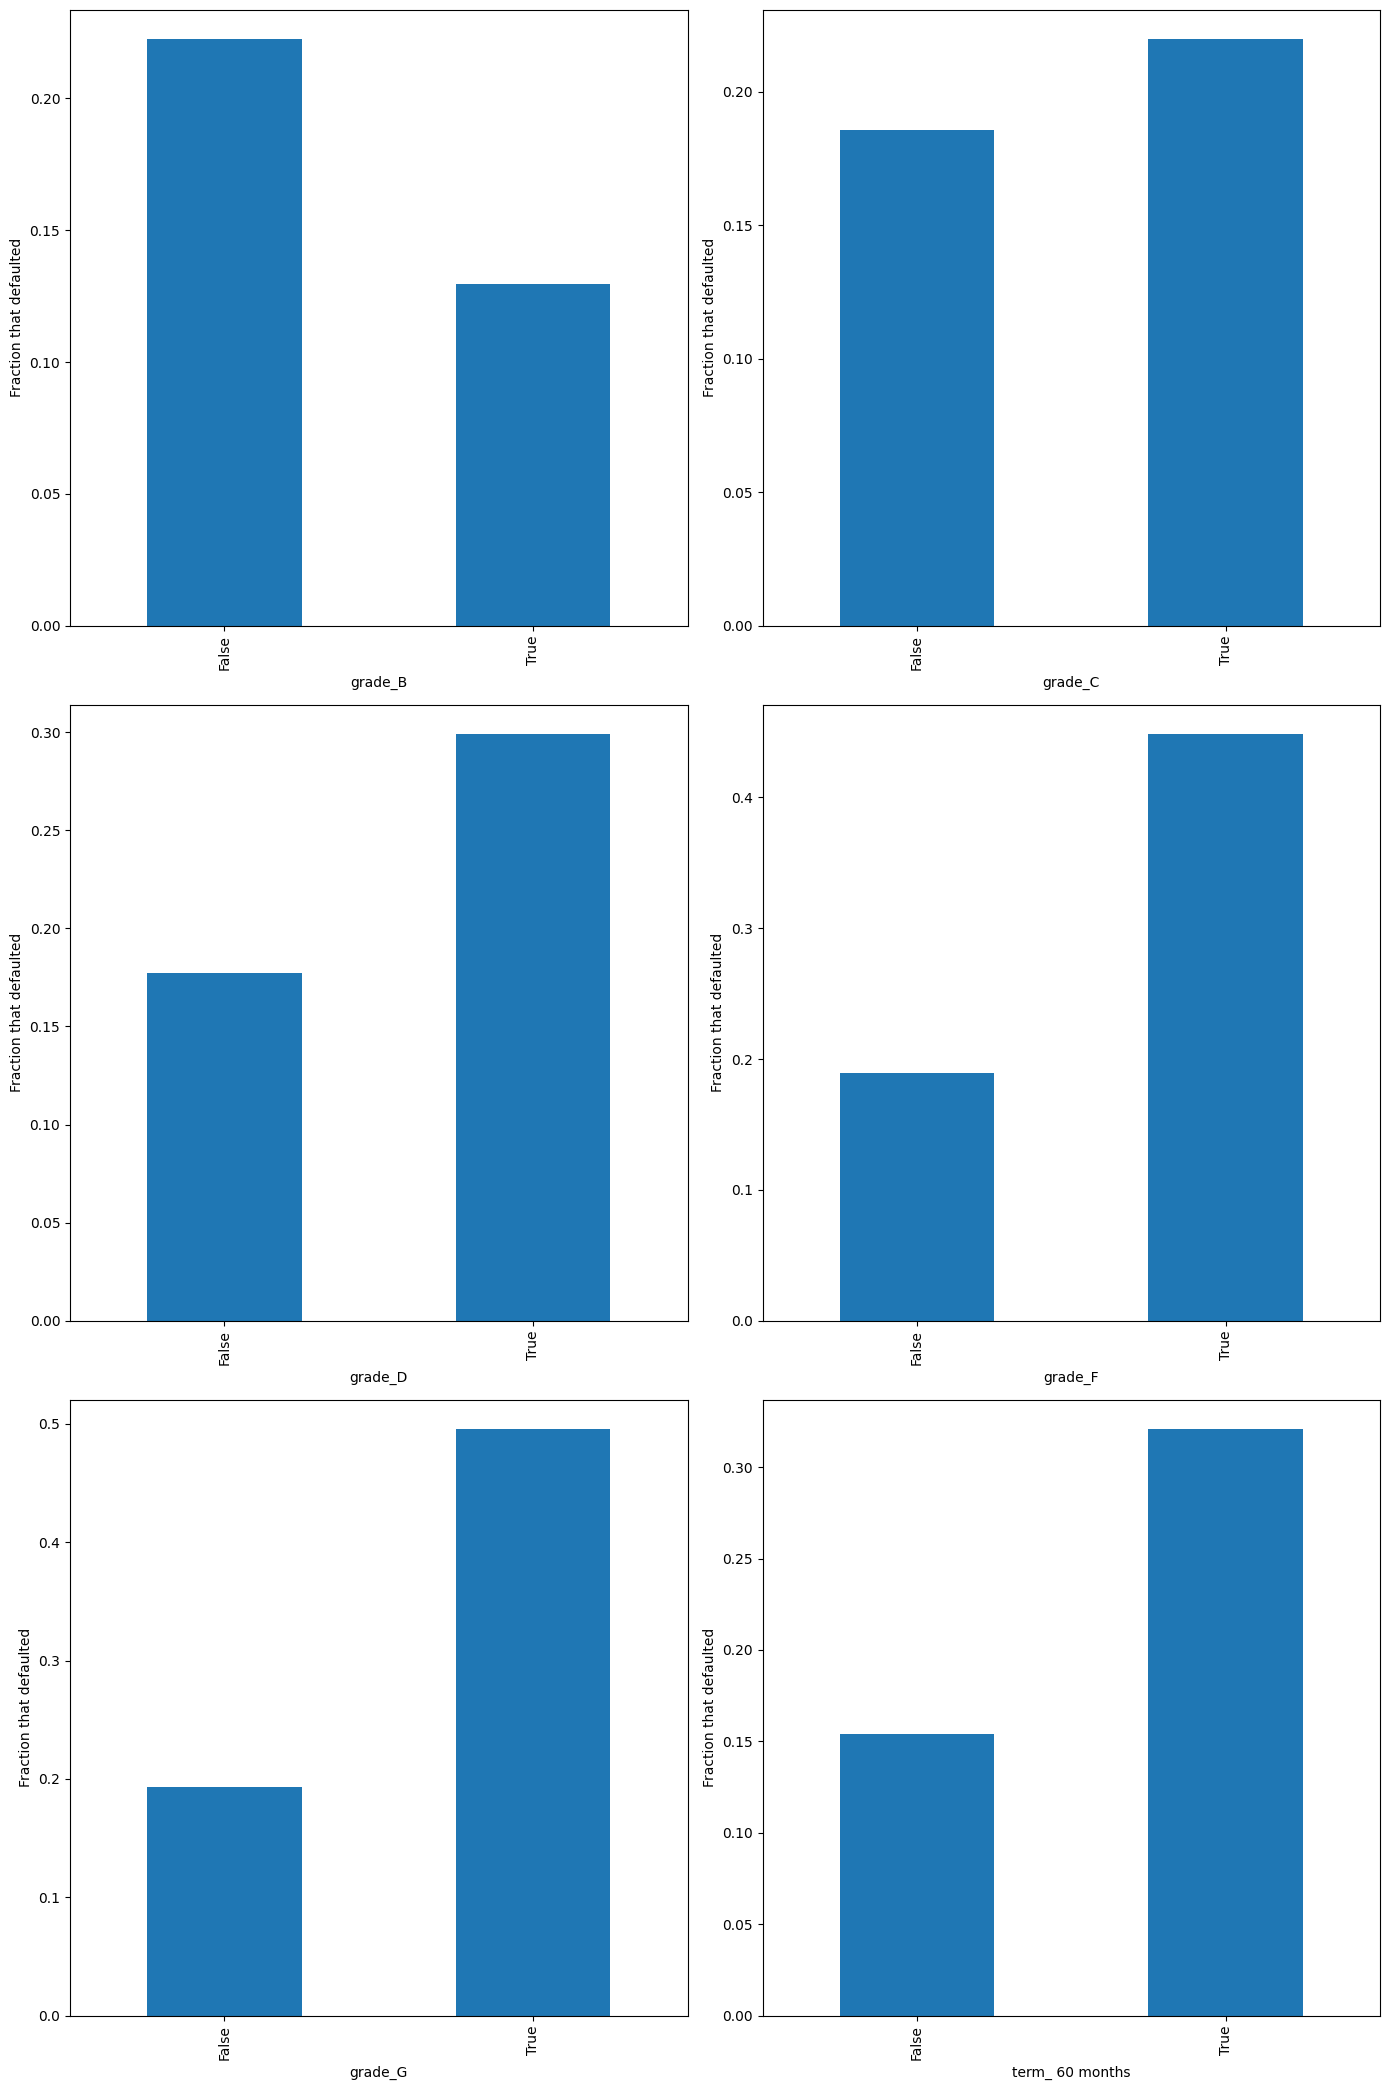

In [46]:
# Loan Grades and Term
categorical_cols = ["grade_B", "grade_C", "grade_D", "grade_F", "grade_G", "term_ 60 months"]
continuous_cols = []
target_col = "default"
predictor_cols = categorical_cols + continuous_cols

# This is to plot everything in a 3x2 space
rows, cols = 3, 2
fig, axs = plt.subplots(ncols=cols, nrows=rows, figsize=(7*cols, 7*rows))
axs = axs.flatten()
posn = 0

# Plot continuous features
for col in continuous_cols:
    sns.boxplot(x=target_col, y=col, data=df, ax=axs[posn])
    axs[posn].set_ylabel(col)
    axs[posn].set_title("")
    posn += 1

# Plot categorical features
for col in categorical_cols:
    df.groupby(col)[target_col].mean().plot(kind="bar", ax=axs[posn])
    axs[posn].set_ylabel("Fraction that defaulted")
    posn += 1

plt.tight_layout()

Loan grades are an assessment of a borrower's credit history done by underwriters. The grade is based off credit history, collateral and repayment prospects. Higher loan grades are "safer", while lower grades are considered riskier. This is reflected in the default data, as only higher grade loans (loan B) have a higher proportion of borrowers who do not default than those who do. This effect only becomes more salient as the loan grade degrades.
Long term loans (> 60 months) also have a higher proportion of defaults.

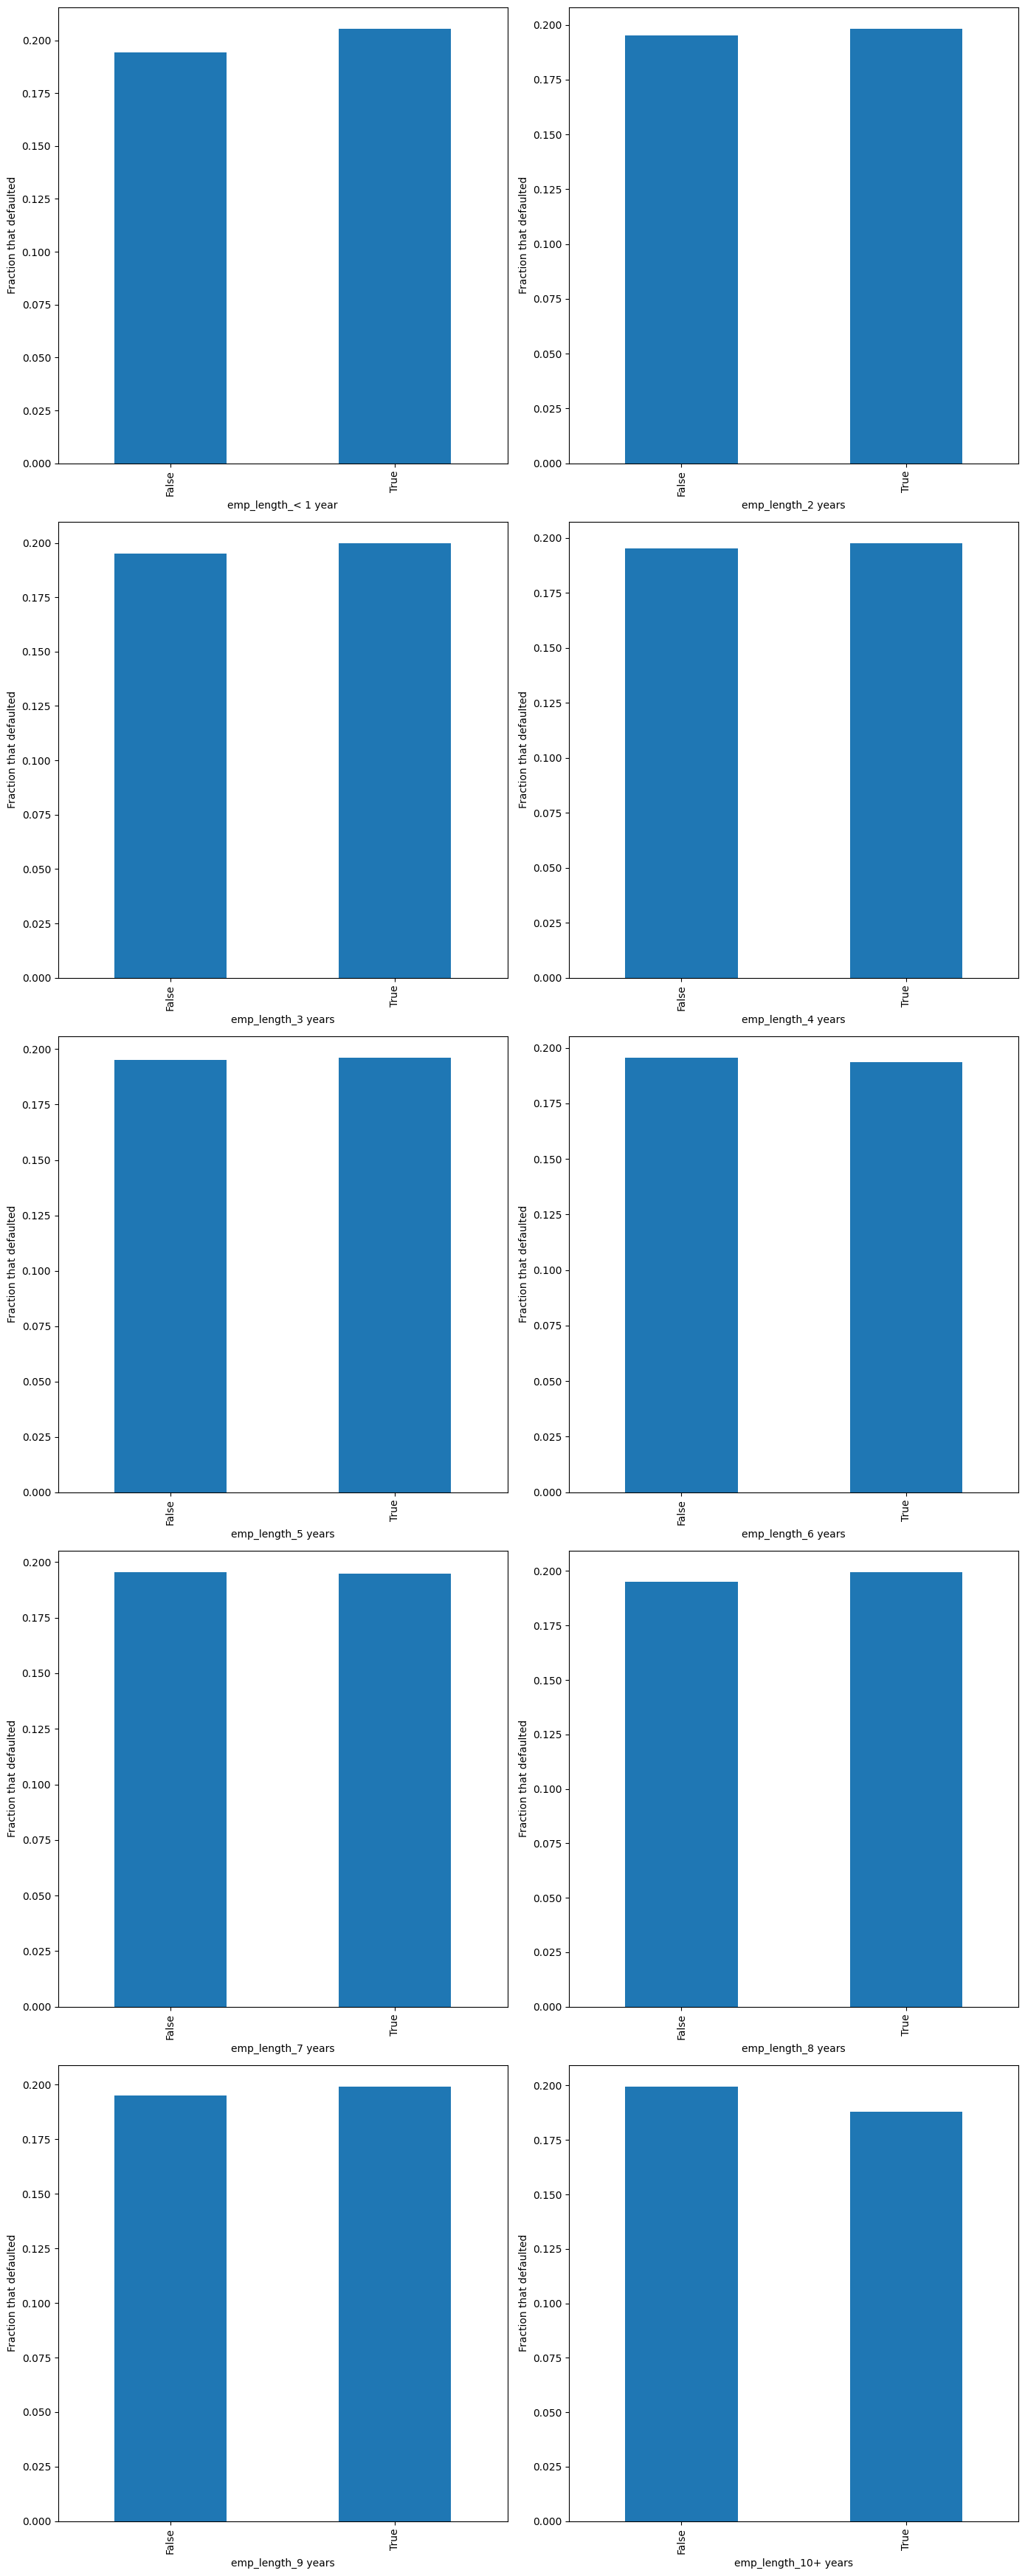

In [35]:
# Employment Length
categorical_cols = ['emp_length_< 1 year',
       'emp_length_2 years', 'emp_length_3 years', 'emp_length_4 years',
       'emp_length_5 years', 'emp_length_6 years', 'emp_length_7 years',
       'emp_length_8 years', 'emp_length_9 years', 'emp_length_10+ years',]
continuous_cols = []
target_col = "default"
predictor_cols = categorical_cols + continuous_cols

# This is to plot everything in a 3x2 space
rows, cols = 5, 2
fig, axs = plt.subplots(ncols=cols, nrows=rows, figsize=(7*cols, 7*rows))
axs = axs.flatten()
posn = 0

# Plot continuous features
for col in continuous_cols:
    sns.boxplot(x=target_col, y=col, data=df, ax=axs[posn])
    axs[posn].set_ylabel(col)
    axs[posn].set_title("")
    posn += 1

# Plot categorical features
for col in categorical_cols:
    df.groupby(col)[target_col].mean().plot(kind="bar", ax=axs[posn])
    axs[posn].set_ylabel("Fraction that defaulted")
    posn += 1

plt.tight_layout()

Employment length seems to have a very small, if any, effect on defaulting. The correlation between employment length is only salient at the extremes ( < 1 year or > 10 years). Having a short employment length (< 1 year) might signify that the loaner is young or recently switched industries due to variety of reasons which do not necessarily reflect on their ability to pay off a loan. It is hard to define a relationship inbetween once a loaner has established semi-stable employment.

In [4]:
pdf = pd.read_csv('/credit allocation/pd_predictions.csv')
pdf.head()

,loan_amnt,default,PD
0,3600.0,0,0.136206
1,24700.0,0,0.145928
2,20000.0,0,0.156412
3,10400.0,0,0.369842
4,11950.0,0,0.203420


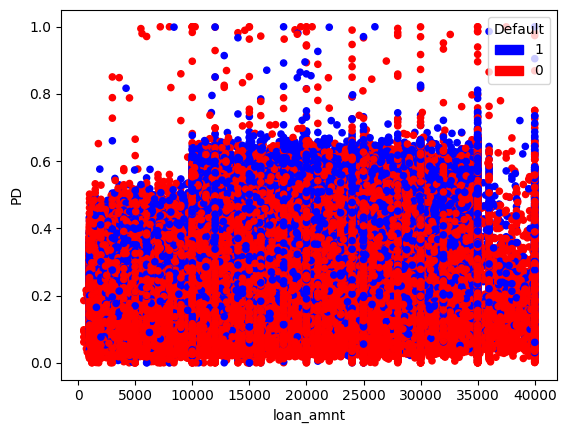

In [26]:
# Model Evaluation
import matplotlib.patches as mpatches

cmap = {1: 'blue', 0: 'red'}
pdf.plot(kind="scatter", x="loan_amnt", y="PD", c=[cmap[c] for c in pdf['default']])
plt.legend(handles=[mpatches.Patch(color=cmap[k], label=k) for k in cmap], loc=1, title="Default", frameon=True)
plt.show()

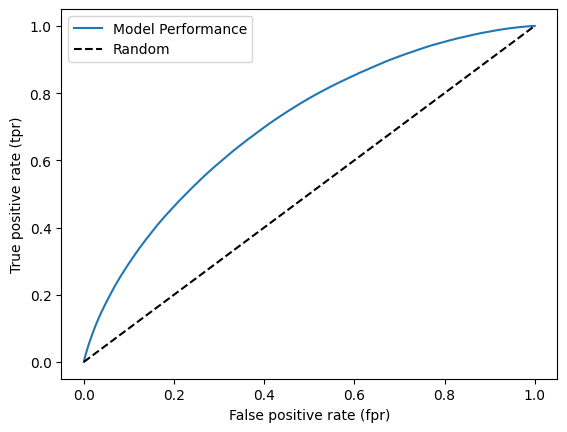

In [31]:
# ROC Curve
fpr, tpr, thresholds = metrics.roc_curve(pdf.default, pdf.PD)
plt.plot(fpr, tpr, label='Model Performance')
plt.xlabel("False positive rate (fpr)")
plt.ylabel("True positive rate (tpr)")
plt.plot([0,1], [0,1], 'k--', label="Random")
plt.legend(loc='best')

ROC Curve is fairly distinct from the random control line, signifying decent model performance



<Figure size 20x20 with 0 Axes>

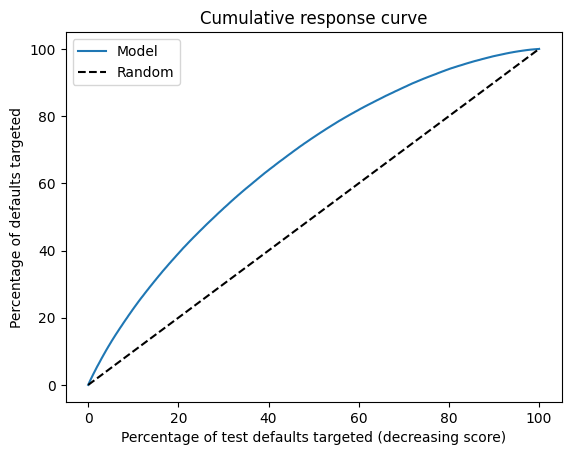

<Figure size 20x20 with 0 Axes>

In [41]:
# Cumulative Response Curve
order = np.argsort(pdf.PD)[::-1]
PD_sorted = pdf.PD[order]
default_sorted = np.array(pdf.default)[order]

x_cumulative = np.arange(len(PD_sorted)) + 1
y_cumulative = np.cumsum(default_sorted)

x_cumulative = np.array(x_cumulative)/float(x_cumulative.max()) * 100
y_cumulative = np.array(y_cumulative)/float(y_cumulative.max()) * 100

plt.plot(x_cumulative, y_cumulative, label='Model')

plt.plot([0,100], [0,100], 'k--', label="Random")
plt.xlabel("Percentage of test defaults targeted (decreasing score)")
plt.ylabel("Percentage of defaults targeted")
plt.title("Cumulative response curve")
plt.legend()
plt.figure(figsize=(.2, .2))

Culmulative Response Curve is fairly distinct from the random control line, signifying decent model performance


In [47]:
df.describe()

,loan_amnt,int_rate,annual_inc,dti,fico_range_low,default
count,1.266782e+06,1.266782e+06,1.266782e+06,1.266782e+06,1.266782e+06,1.266782e+06
mean,1.460112e+04,1.323370e+01,7.790051e+04,1.812865e+01,6.961255e+02,1.953185e-01
std,8.746531e+03,4.769519e+00,7.108291e+04,9.569931e+00,3.166259e+01,3.964459e-01
min,5.000000e+02,5.310000e+00,3.300000e+01,-1.000000e+00,6.250000e+02,0.000000e+00
25%,8.000000e+03,9.750000e+00,4.800000e+04,1.176000e+01,6.700000e+02,0.000000e+00
50%,1.207500e+04,1.274000e+01,6.500000e+04,1.752000e+01,6.900000e+02,0.000000e+00
75%,2.000000e+04,1.599000e+01,9.250000e+04,2.391000e+01,7.100000e+02,0.000000e+00
max,4.000000e+04,3.099000e+01,1.099920e+07,9.990000e+02,8.450000e+02,1.000000e+00


Text(0.5, 1.0, 'Profit curve')

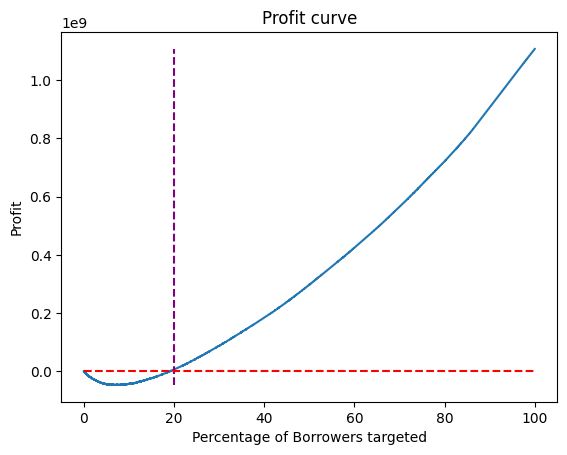

In [52]:
# Assuming a constant interest rate of 13.2% (Mean of the training data)
# Define profit as loan amount * interest rate
# Assume 70% of the loan is paid off before default and the remaining loan as loss
loan_sorted = np.array(pdf.loan_amnt)[order]
profit = (loan_sorted * (1-default_sorted)) * 0.132 + (loan_sorted * (default_sorted)) * 0.132 * 0.7 - (loan_sorted * (default_sorted)) * 0.3
profits = np.cumsum(profit)
plt.plot(x_cumulative, profits)
plt.vlines(x=20, ymin=min(0, profits.min()), ymax=profits.max(), color='purple', linestyles='--')
plt.hlines(y=0, xmin=0, xmax=100, color='red', linestyles='--')
plt.xlabel("Percentage of Borrowers targeted")
plt.ylabel("Profit")
plt.title("Profit curve")

As shown above, with the assumptions made, a threshold of taking the highest 20% PD borrowers would ensure breakeven profit.

However, the profit curve is highly dependent on many variables. Simole assumptions were made here to demonstrate the utility of a decision model in securing profit, but we can integrate the following factors to build a more accurate profit model to evaluate different decision thresholds:
* Current balance on the loan
* Amount on the loan paid
* Paid interest
* Paid late fees